### **Figure 3: _Loss of keratin expression diminishes EVL epiboly movements_ Notebook**

This notebook provides tools and data to recreate the figure 3 from Naik et al 2026. 
It has been modified code from the original [repo](https://github.com/Suyash-Naik/PaperPythonScripting) to allow for all orginal source data retrival from the repository and plotting using standarized versions of the code to plot the figures. 

**Author**: Suyash Naik

In [30]:
#Import block
from src.BinnedPlotter import BinnedIntensityPlotter
import matplotlib.patches as mpatches
from src.Figureplot import setup_figure
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import re 

### **Figure 7C**: _Plot of epiboly speed with keratin YSL morpholino_

Plot of EVL epiboly movement speed as a function of time (hpf) during epiboly in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos injected with 2ng control MO (green) (N = 4, n = 8 embryos ) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue) (N = 4, n = 7 embryos) into the YSL at sphere stage (3.3 hpf). Error bars as ribbon SD of mean.

In [4]:
yslspeed=pd.read_csv("data/Fig7/7C/YSLK4K8MOSpeedData.csv")
controlcols=[col for col in yslspeed.columns if "control" in col]
morphantcols=[col for col in yslspeed.columns if "ysl" in col]
controlmean=np.nanmean(yslspeed[controlcols],axis=1)
controlsem=np.nanstd(yslspeed[controlcols],axis=1)
morphantmean=np.nanmean(yslspeed[morphantcols],axis=1)
morphantsem=np.nanstd(yslspeed[morphantcols],axis=1)

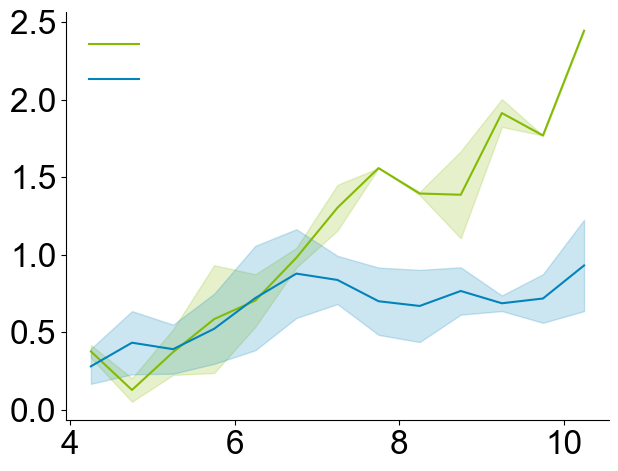

In [8]:
fig,ax=setup_figure()
ax.plot(yslspeed["Time (hpf)"],controlmean,color='#83bb03',label="     ")
ax.fill_between(yslspeed["Time (hpf)"],controlmean-controlsem,controlmean+controlsem,alpha=0.2,color="#83bb03")  
ax.plot(yslspeed["Time (hpf)"],morphantmean,color="#0383bb",label="     ")
ax.fill_between(yslspeed["Time (hpf)"],morphantmean-morphantsem,morphantmean+morphantsem,alpha=0.2,color="#0383bb")  
plt.legend(loc="upper left",frameon=False,fontsize=18)
plt.show()    

### **Figure 7D**: _Actin retrograde flow in morphants_

Plot of retrograde actin flow velocity in the YSL as a function of distance from the EVL-YSL boundary in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos at shield stage (6 hpf) injected with 2 ng control MO (green)(N = 3, n = 6 embryos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue) (N = 3, n = 6 embryos) into the YSL at sphere stage (3.3 hpf). 

Error bars as ribbon SD of mean.

In [32]:
controldict=pickle.load(open("data/Fig7/7D/Controldict.pkl","rb"))
ysldict=pickle.load(open("data/Fig7/7D/YSLdict.pkl","rb"))
controlflow=pd.read_csv("data/Fig7/7D/Control_Flowprofile.csv")
yslflow=pd.read_csv("data/Fig7/7D/YSL_Mo_Flowprofile.csv")
def plot_magdict(magdict):
    for key in magdict.keys():
        plt.plot(magdict[key][0],label=key)
        plt.fill_between(np.arange(len(magdict[key][0])),magdict[key][0]-magdict[key][1],magdict[key][0]+magdict[key][1],alpha=0.5)
def plot_averagemagdict(magdict,dictname:str):
    mean_magdict={}
    for key in magdict.keys():
        mean_magdict[key]=magdict[key][0]
    df=pd.DataFrame(mean_magdict)
    dfmean=df.mean(axis=1)
    dfstd=df.sem(axis=1)
    if dictname=="    ":
        colorname="#83bb03"
    else:
        colorname="#0383bb"
    plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower
    plt.rcParams['font.size'] = 24
    plt.rcParams['savefig.dpi'] = 300
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    plt.gca().spines['right'].set_color('none')
    plt.gca().spines['top'].set_color('none')
    #plt.ylabel("Flow velocity(µm/s)")
    plt.plot(dfmean,color=colorname,label=dictname)
    plt.fill_between(dfmean.index,dfmean-dfstd,dfmean+dfstd,alpha=0.3,color=colorname)
    plt.gca().invert_yaxis()

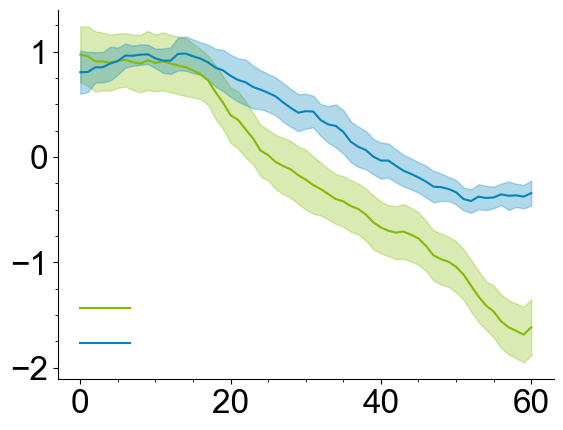

In [36]:
plot_averagemagdict(controldict,  "    ")
plot_averagemagdict(ysldict, "        ")
plt.legend(loc="lower left",frameon=False,fontsize=18)
plt.xticks(np.arange(0,60,5),minor=True)
plt.yticks(np.arange(-2,1.5,0.25),minor=True)
plt.show()

### **Figure 7E**: _Plot of epiboly speed with keratin YSL morpholino_

Box plot of actin intensity in a fixed region of interest (ROI) within the YSL close to the point of micropipette aspiration before (pre Asp) and after (post Asp) aspiration in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos at 3.3 hpf injected with 2 ng control MO (green boxes, N = 3 n = 10 embryos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue boxes N = 3 n= 13 embryos)  into the YSL at sphere stage (3.3 hpf). N = 4, n = 13 embryos. 

Boxes represent quartiles of the data and error bars the spread (pvalues: ***<0.001, **<00.1 paired t test).

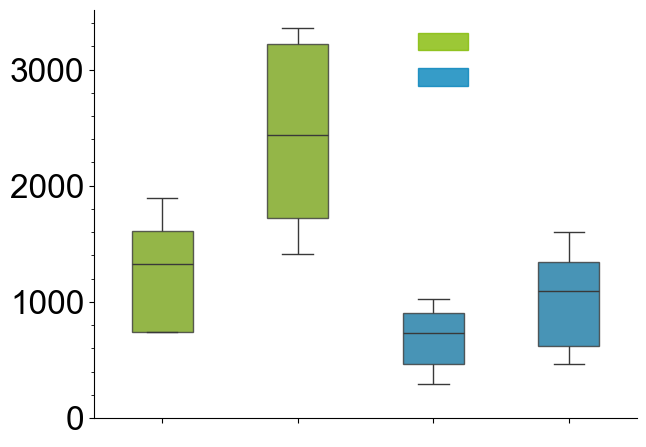

In [13]:
actinaspdf=pd.read_csv("data/Fig7/7E/AspAnalysisBox_2024_Figure5.csv")
fig,ax=setup_figure()
colors = ["#83bb03", "#83bb03", "#0383bb", "#0383bb"]
ax=sns.boxplot(data=actinaspdf, x="Sampleid", y="Intensity", hue="Sampleid", legend="auto", palette=colors, width=0.45, boxprops=dict(alpha=.8))
red_patch = mpatches.Patch(color="#83bb03", label='                  ', alpha=0.8)
blue_patch = mpatches.Patch(color="#0383bb", label='                  ', alpha=0.8)
# Set the x-axis tick labels
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["", "", "", ""])
ax.set_yticks(np.arange(0,3600,200),minor=True)
# Add the legend
ax.legend(handles=[red_patch, blue_patch],frameon=False,fontsize=18)
plt.xlabel(None)
plt.ylabel(None)
plt.show()

### **Figure 7F**: _Actin alignment in ysl flows_

Box plot of actin flow alignment within the YSL at 6 hpf in Tg(actb2: Utrophin-mcherry, krt18:Krt18GFP) embryos injected with 2 ng control MO (green boxes, N = 3 n = 6 emrbyos) or 1 ng keratin 4 plus 1 ng keratin 8 MO (blue boxes, N=3 n =6 embryos)  into the YSL at sphere stage (3.3 hpf). 

Boxes represent quartiles of the data and error bars the spread. (***<0.001, paired t test).

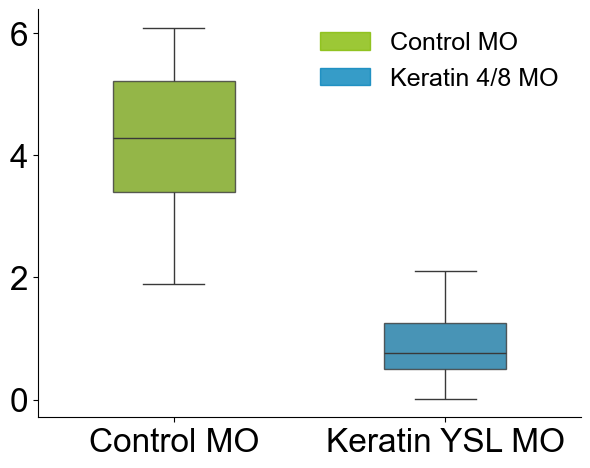

In [25]:
alignmentdata = pd.read_csv("data/Fig7/7F/YSLalignment.csv")
alignmentdata.drop(columns=alignmentdata.columns[:2], inplace=True)

alignmentdata_long = pd.melt(alignmentdata, id_vars=alignmentdata.columns[2:], 
                              var_name='Sample', value_name='Alignment')

fig, ax = setup_figure()
colors = ["#83bb03", "#0383bb"]
sns.boxplot(data=alignmentdata_long, x="Sample", y="Alignment", hue="Sample",palette=colors, width=0.45, boxprops=dict(alpha=.8))
red_patch = mpatches.Patch(color="#83bb03", label='Control MO', alpha=0.8)
blue_patch = mpatches.Patch(color="#0383bb", label='Keratin 4/8 MO', alpha=0.8)
ax.legend(handles=[red_patch, blue_patch], frameon=False, fontsize=18)
plt.xlabel(None)
plt.ylabel(None)
plt.show()